In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display

# Import AI Tools từ Scikit-Learn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

sns.set_theme(style="whitegrid")

df_modeling = pd.read_csv('../data/processed/retail_features_clean.csv')
print(f"Data shape: {df_modeling.shape}")
print("Ready for K-Means!")

Data shape: (4238, 22)
Ready for K-Means!


In [80]:
K_MAX = 10
k_values = range(2, K_MAX + 1)
inertia_values = []
silhouette_scores = []

print(f"Training K-Means from K=2 to K={K_MAX}...")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(df_modeling)
    
    # Lưu lại chỉ số
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_modeling, labels))
    print(f"  Tested K={k:2d}: Inertia = {kmeans.inertia_:.2f}, Silhouette = {silhouette_scores[-1]:.4f}")

Training K-Means from K=2 to K=10...
  Tested K= 2: Inertia = 3165200157.46, Silhouette = 0.6236
  Tested K= 3: Inertia = 1397110377.35, Silhouette = 0.5898
  Tested K= 4: Inertia = 788027914.48, Silhouette = 0.5703
  Tested K= 5: Inertia = 495372449.78, Silhouette = 0.5653
  Tested K= 6: Inertia = 346168886.67, Silhouette = 0.5556
  Tested K= 7: Inertia = 253897996.78, Silhouette = 0.5505
  Tested K= 8: Inertia = 195681895.34, Silhouette = 0.5439
  Tested K= 9: Inertia = 152929786.23, Silhouette = 0.5438
  Tested K=10: Inertia = 122853409.28, Silhouette = 0.5448


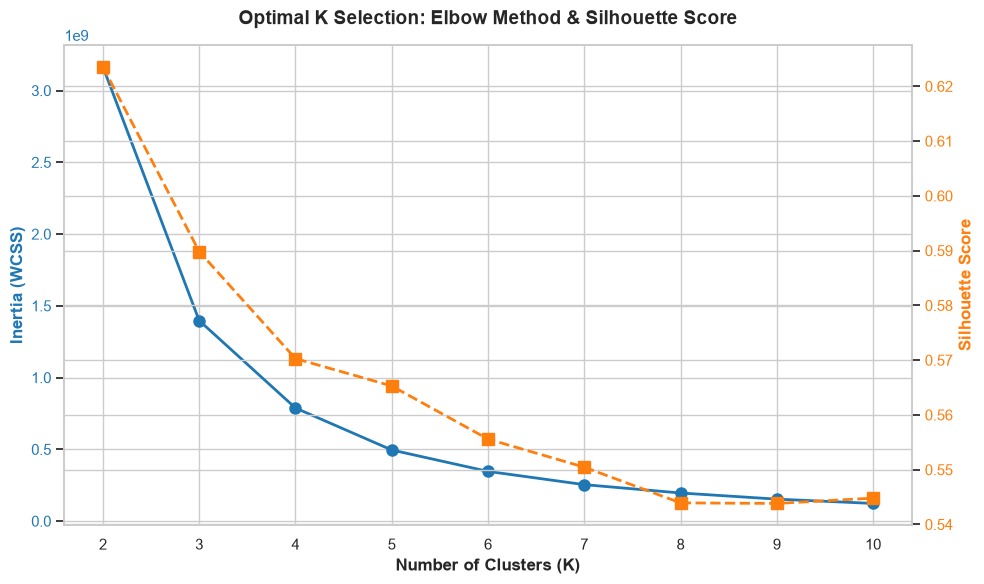

In [81]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Inertia (WCSS)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(k_values, inertia_values, marker='o', color=color1, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(k_values)

ax2 = ax1.twinx()  
color2 = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color2, fontsize=12, fontweight='bold')
ax2.plot(k_values, silhouette_scores, marker='s', color=color2, linewidth=2, markersize=8, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color2)

# Thêm tiêu đề và căn chỉnh
plt.title('Optimal K Selection: Elbow Method & Silhouette Score', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()  
plt.show()

### Observation:
* According to the Elbow Method (Inertia), the curve starts to flatten around $K=3$ or $K=4$, suggesting these as potential optimal values.
* However, the Silhouette Score peaks strongly at $K=2$. From a business perspective, segmenting the customer base into just two broad groups is too simplistic and not efficient for targeted marketing.
* Therefore, relying on a single metric creates a conflict between mathematical optimization and business utility. We need a more comprehensive evaluation metric.

---

###  Resolving Metric Conflicts with a Composite Score

**The Approach:**
To resolve the trade-off between cluster compactness and cluster separation, we introduce a **Composite Score**. This approach synthesizes multiple clustering validation metrics into a single, normalized index. We evaluate three complementary metrics:

1. **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters (higher is better).
2. **Davies-Bouldin Index (DB):** Measures the ratio of intra-cluster scatter to inter-cluster separation (lower is better).
3. **Calinski-Harabasz Index (CH):** Evaluates the variance ratio between clusters versus within clusters (higher is better).

**The Formula:**
To combine these metrics, we inverse the DB index and normalize the CH index, assigning a $50\%$ weight to the Silhouette score (as it is the most intuitive geometric metric) and $25\%$ to the others. 

$$Composite = 0.5 \cdot Silhouette + 0.25 \cdot \frac{1}{1 + DB} + 0.25 \cdot \frac{CH}{CH_{max}}$$



In [82]:
K_MAX = 7
k_values = range(2, K_MAX + 1)
metrics_list = []

for k in range (2, 7) :
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(df_modeling)
    
    sil = silhouette_score(df_modeling, labels)
    db = davies_bouldin_score(df_modeling, labels)
    ch = calinski_harabasz_score(df_modeling, labels)

    metrics_list.append({
        'k': k,
        'Silhouette': sil,
        'Davies_Bouldin': db,
        'Calinski_Harabasz': ch
    })
    print(f"  Tested K={k}: Silhouette = {sil:.4f}, DB = {db:.4f}, CH = {ch:.1f}")

metrics_df = pd.DataFrame(metrics_list)

print(metrics_df) 

  Tested K=2: Silhouette = 0.6236, DB = 0.5040, CH = 12525.0
  Tested K=3: Silhouette = 0.5898, DB = 0.4997, CH = 16864.4
  Tested K=4: Silhouette = 0.5703, DB = 0.5016, CH = 21019.0
  Tested K=5: Silhouette = 0.5653, DB = 0.4960, CH = 25696.7
  Tested K=6: Silhouette = 0.5556, DB = 0.5001, CH = 29775.9
   k  Silhouette  Davies_Bouldin  Calinski_Harabasz
0  2    0.623554        0.503970       12525.048193
1  3    0.589831        0.499667       16864.431529
2  4    0.570283        0.501619       21018.991671
3  5    0.565285        0.495961       25696.709463
4  6    0.555588        0.500145       29775.885597


In [83]:
ch_max = metrics_df["Calinski_Harabasz"].max()

metrics_df["Composite"] = (
    0.5 * metrics_df["Silhouette"]
    + 0.25 / (1 + metrics_df["Davies_Bouldin"])
    + 0.25 * (metrics_df["Calinski_Harabasz"] / ch_max)
)

print("\n--- BẢNG TỔNG HỢP CÁC CHỈ SỐ ---")
print(metrics_df.round(4).set_index('k'))


--- BẢNG TỔNG HỢP CÁC CHỈ SỐ ---
   Silhouette  Davies_Bouldin  Calinski_Harabasz  Composite
k                                                          
2      0.6236          0.5040         12525.0482     0.5832
3      0.5898          0.4997         16864.4315     0.6032
4      0.5703          0.5016         21018.9917     0.6281
5      0.5653          0.4960         25696.7095     0.6655
6      0.5556          0.5001         29775.8856     0.6944


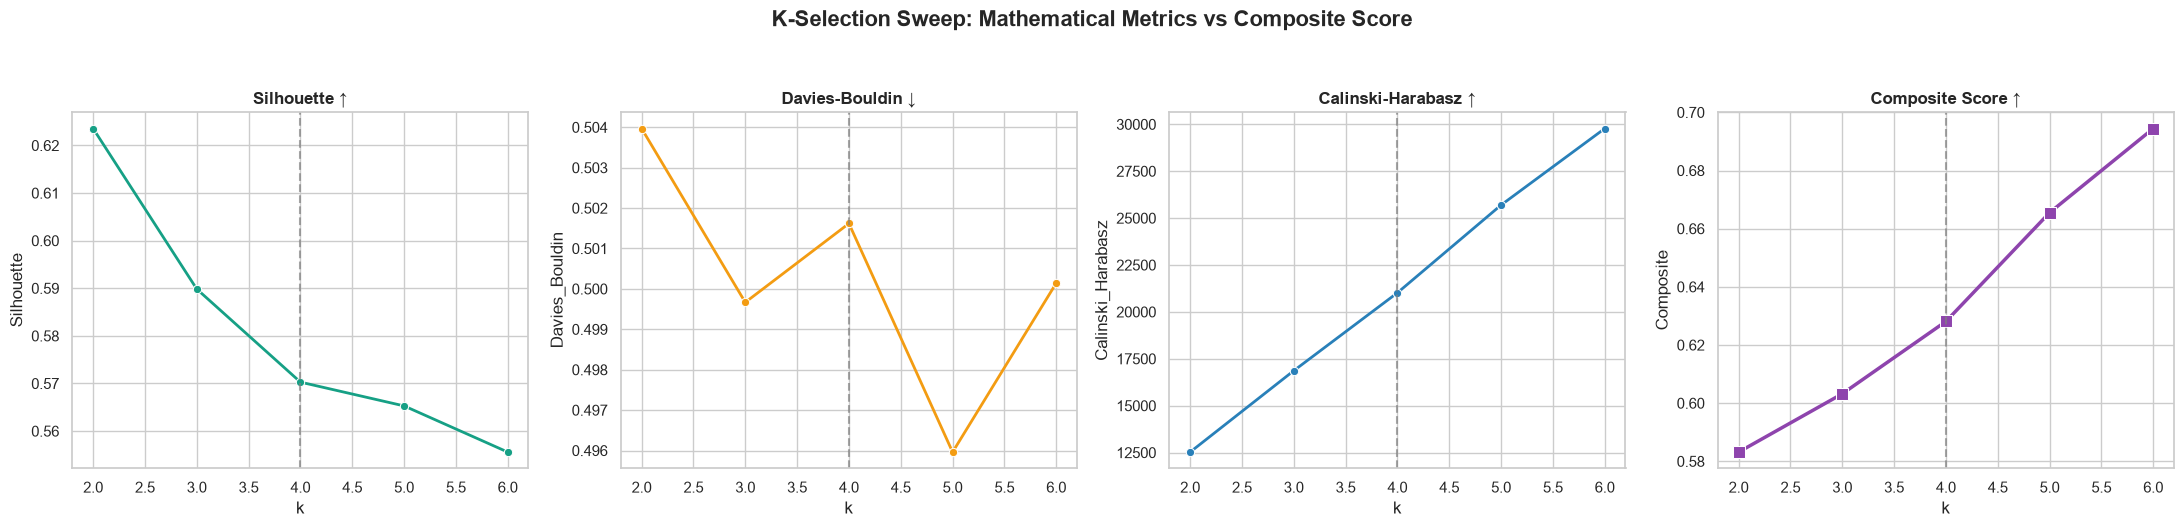

In [84]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 1. Silhouette (higher is better)
sns.lineplot(data=metrics_df, x='k', y='Silhouette', marker='o', ax=axes[0], color='#16a085', linewidth=2)
axes[0].set_title('Silhouette ↑', fontsize=12, fontweight='bold')
axes[0].axvline(4, color='gray', linestyle='--', alpha=0.7) 

# 2. Davies-Bouldin (Lower is better)
sns.lineplot(data=metrics_df, x='k', y='Davies_Bouldin', marker='o', ax=axes[1], color='#f39c12', linewidth=2)
axes[1].set_title('Davies-Bouldin ↓', fontsize=12, fontweight='bold')
axes[1].axvline(4, color='gray', linestyle='--', alpha=0.7)

# 3. Calinski-Harabasz (Higher is better)
sns.lineplot(data=metrics_df, x='k', y='Calinski_Harabasz', marker='o', ax=axes[2], color='#2980b9', linewidth=2)
axes[2].set_title('Calinski-Harabasz ↑', fontsize=12, fontweight='bold')
axes[2].axvline(4, color='gray', linestyle='--', alpha=0.7)

# 4. Composite Score
sns.lineplot(data=metrics_df, x='k', y='Composite', marker='s', ax=axes[3], color='#8e44ad', linewidth=2.5, markersize=8)
axes[3].set_title('Composite Score ↑', fontsize=12, fontweight='bold')
axes[3].axvline(4, color='gray', linestyle='--', alpha=0.7)

plt.suptitle('K-Selection Sweep: Mathematical Metrics vs Composite Score', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Optimal K Selection: The Business-Math Bridge

**1. The Mathematical Dilemma**

Observing the evaluation metrics, we encounter a statistical divergence:
* **$K=2$** emerges as the geometrically optimal choice, where the Silhouette score peaks and the Davies-Bouldin index bottoms out.
* **$K > 5$** is favored by the upward trends of the Calinski-Harabasz index and the Composite Score.

**2. The Business Reality**

Although $K=2$ achieves the highest geometric scores, cluster profiling reveals that it merely segments the customer base into two generic groups: frequent and infrequent buyers. This binary division is too superficial and lacks the necessary depth to drive personalized marketing campaigns. Conversely, selecting a very high $K$ (e.g., $K=6$) dilutes the segments, leading to an inefficient allocation of marketing resources.

**3. The Strategic Choice: $K=3$ or $K=4$**

**$K=4$** is selected as the minimum threshold capable of fully isolating highly specific behavioral groups:
* **At $K=3$:** Purchasing rhythms related to seasonality remain entangled across clusters, failing to exhibit a clear seasonal concentration.
* **At $K=4$:** The dimensional space expands just enough to successfully isolate highly valuable and distinct subsets, specifically extracting the **Seasonal Intensives** (concentrated seasonal spenders) and the **High-Return Actives** (high spenders with a dominant return rate).

**Conclusion:** 
The decision to proceed with **$K=4$** represents the perfect compromise between a stable mathematical structure and core business utility, ensuring that each generated segment can be translated into a distinct, actionable marketing strategy.

In [85]:
test_k_values = [2, 3, 4]
profiles_dict = {}

for k in test_k_values:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(df_modeling)
    
    profiles_dict[k] = df_modeling.groupby(labels).median()

print("="*70)
print(profiles_dict[2].round(2).T)

                             0         1
CustomerID            16774.50  13814.50
Recency                   0.02      0.03
InterPurchaseCV          -0.47     -0.47
MonthlyOrderRate          0.11      0.11
RecencyAnomaly            0.15      0.15
AOV                      -0.05      0.05
AIV                      -0.01      0.01
MaxSpendShare            -0.22     -0.22
SpendAcceleration        -0.02     -0.02
PriceCV                  -0.03      0.04
BasketSizeCV              0.23      0.23
MedianBasketQty          -0.03      0.03
SingleItemOrderRate      -0.19     -0.19
OrderDiversiy             0.12     -0.10
RepeatSKUFraction         0.23      0.23
NewSKURate                0.19      0.19
BulkLineRate              0.12      0.16
QuantityCV                0.07     -0.03
SKU_HHI                  -0.01     -0.01
BurstIndex               -0.31     -0.31
ReturnRate               -0.53     -0.53
QuarterConcentration     -0.43     -0.43


### Observation

- At $K=2$, our model just split customers into 2 group. Most feature of 2 group are the same, meaning this is not effient. That why we reject this K value


In [87]:

print("At K=3:")
print(profiles_dict[3].round(2).T)

print("At K=4:")
print(profiles_dict[4].round(2).T)

At K=3:
                             0         1         2
CustomerID            15288.00  17291.50  13304.00
Recency                   0.03      0.00      0.04
InterPurchaseCV          -0.47     -0.47     -0.47
MonthlyOrderRate          0.11      0.11      0.11
RecencyAnomaly            0.15      0.15      0.15
AOV                       0.01     -0.09      0.08
AIV                       0.02     -0.04      0.02
MaxSpendShare            -0.23     -0.22     -0.22
SpendAcceleration        -0.02     -0.02     -0.02
PriceCV                  -0.03     -0.02      0.08
BasketSizeCV              0.23      0.23      0.23
MedianBasketQty           0.00     -0.06      0.05
SingleItemOrderRate      -0.19     -0.19     -0.19
OrderDiversiy             0.01      0.17     -0.15
RepeatSKUFraction         0.22      0.23      0.23
NewSKURate                0.19      0.19      0.19
BulkLineRate              0.13      0.11      0.17
QuantityCV                0.02      0.09     -0.05
SKU_HHI                

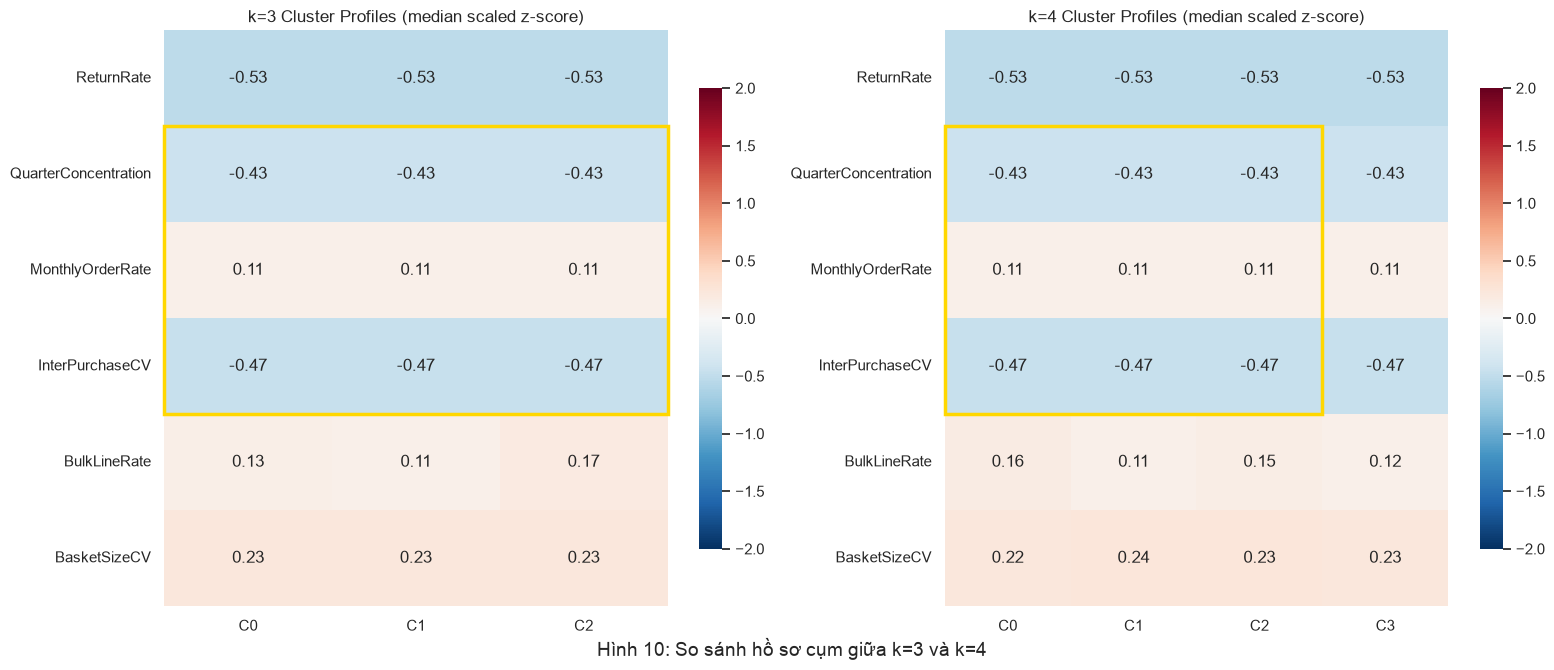

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.patches as patches

# 1. Khởi tạo và huấn luyện 2 mô hình KMeans (k=3 và k=4)
km3 = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
labels_k3 = km3.fit_predict(df_modeling)

km4 = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=42)
labels_k4 = km4.fit_predict(df_modeling)

# 2. Chọn các đặc trưng muốn hiển thị giống trong ảnh
features = [
    'ReturnRate', 
    'QuarterConcentration', 
    'MonthlyOrderRate', 
    'InterPurchaseCV', 
    'BulkLineRate', 
    'BasketSizeCV'
]

# Tính trung vị (median) cho từng cụm và chuyển vị (.T) để đưa đặc trưng ra hàng
med_k3 = df_modeling.groupby(labels_k3)[features].median().T
med_k4 = df_modeling.groupby(labels_k4)[features].median().T

# Đổi tên cột thành tên cụm (vd: C0, C1, C2...)
med_k3.columns = [f"C{c}" for c in med_k3.columns]
med_k4.columns = [f"C{c}" for c in med_k4.columns]

# 3. Vẽ biểu đồ Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cmap = 'RdBu_r'

# Vẽ k=3
sns.heatmap(med_k3, annot=True, fmt=".2f", cmap=cmap, center=0, 
            vmin=-2.0, vmax=2.0, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title("k=3 Cluster Profiles (median scaled z-score)")
axes[0].tick_params(axis='y', rotation=0)

# Vẽ k=4
sns.heatmap(med_k4, annot=True, fmt=".2f", cmap=cmap, center=0, 
            vmin=-2.0, vmax=2.0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title("k=4 Cluster Profiles (median scaled z-score)")
axes[1].tick_params(axis='y', rotation=0)

# 4. Thêm khung viền vàng cho các đặc trưng mùa vụ (QuarterConcentration -> InterPurchaseCV)
# Vị trí y bắt đầu từ 1 (hàng thứ 2), chiều cao là 3 hàng
for ax in axes:
    # Tham số: (x, y), width, height
    rect = patches.Rectangle((0, 1), med_k3.shape[1], 3, linewidth=2.5, 
                             edgecolor='gold', facecolor='none', clip_on=False)
    ax.add_patch(rect)

plt.suptitle("Hình 10: So sánh hồ sơ cụm giữa k=3 và k=4", y=0.02, fontsize=14)
plt.tight_layout()
plt.show()

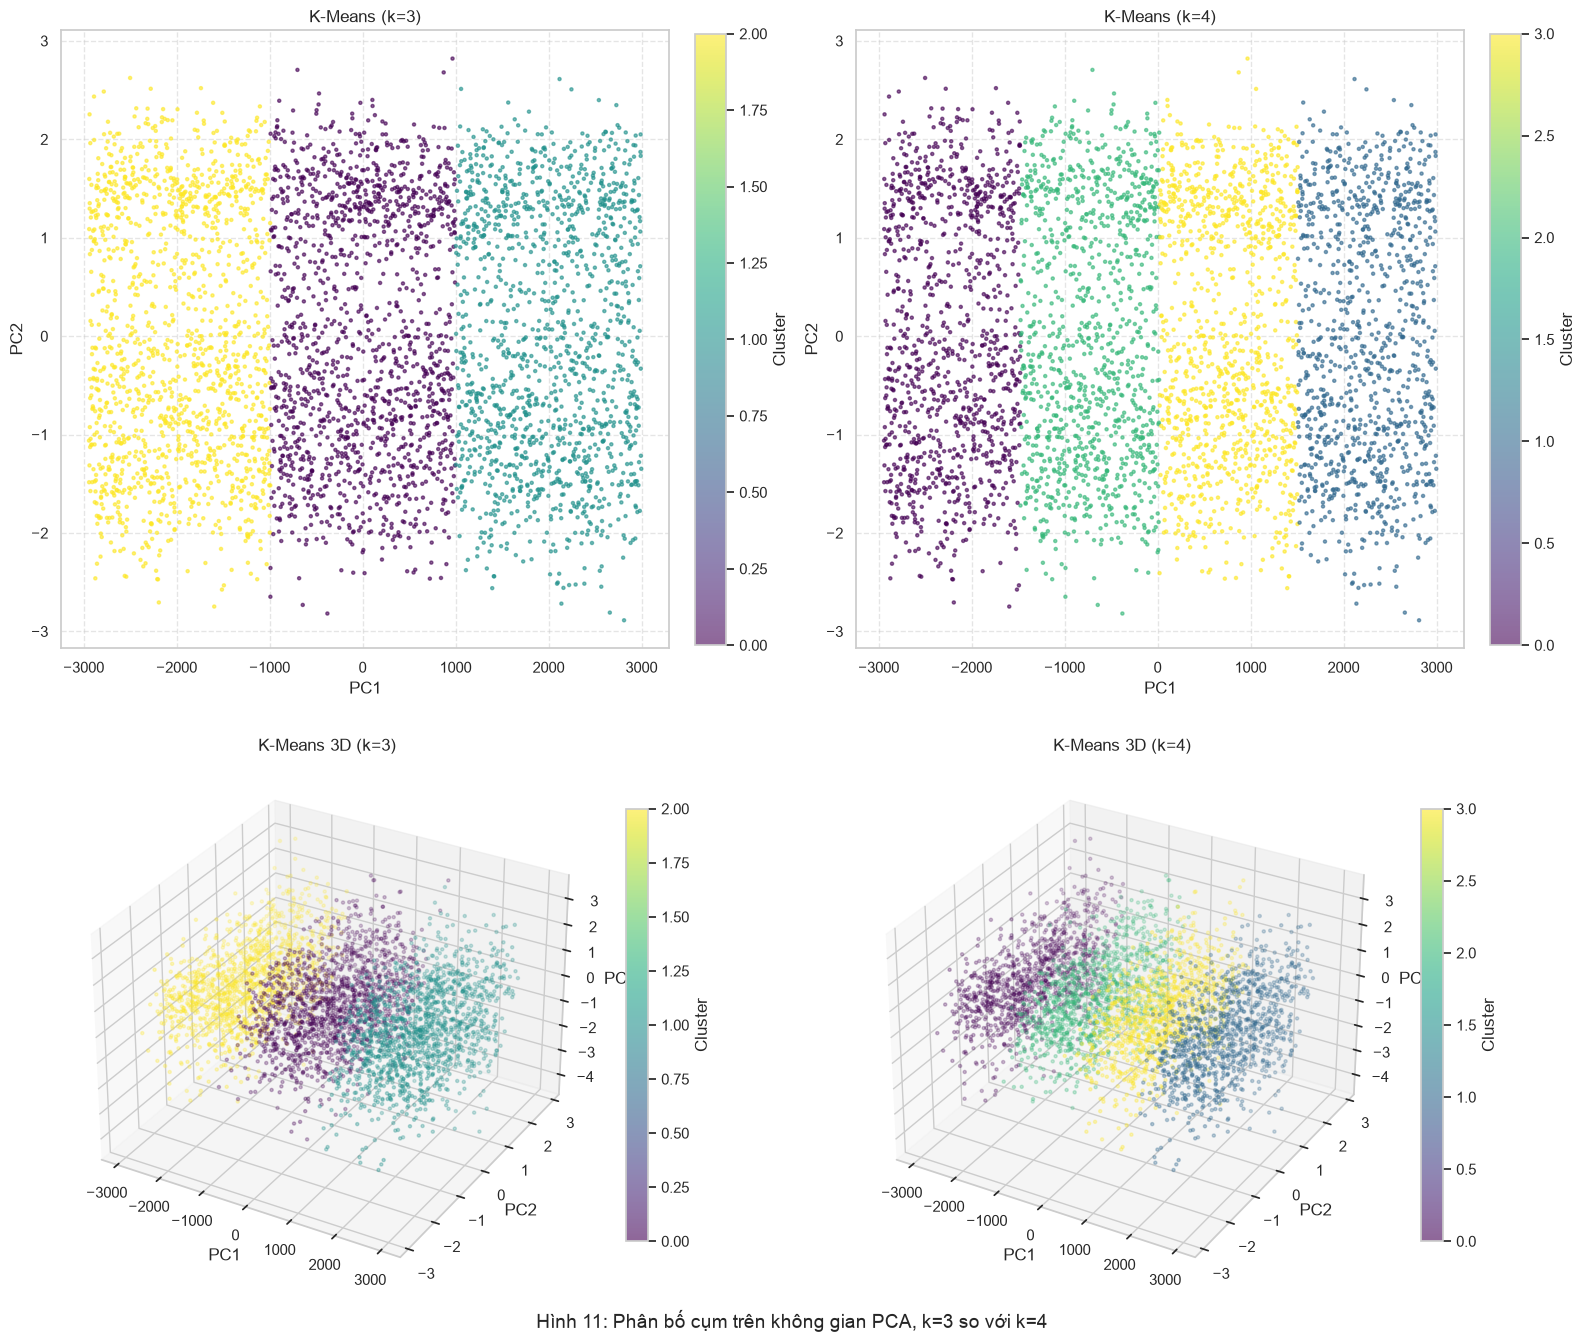

In [89]:
from sklearn.decomposition import PCA

# 1. Chạy PCA giảm xuống 3 chiều
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(df_modeling)

pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]
pc3 = X_pca[:, 2]

# 2. Thiết lập lưới biểu đồ 2x2
fig = plt.figure(figsize=(16, 14))
cmap_scatter = 'viridis'

# --- HÀNG 1: BIỂU ĐỒ 2D ---

# 2D Plot cho k=3
ax1 = fig.add_subplot(2, 2, 1)
scatter1 = ax1.scatter(pc1, pc2, c=labels_k3, cmap=cmap_scatter, s=5, alpha=0.6)
ax1.set_title("K-Means (k=3)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.grid(True, linestyle='--', alpha=0.5)
fig.colorbar(scatter1, ax=ax1, label="Cluster", fraction=0.046, pad=0.04)

# 2D Plot cho k=4
ax2 = fig.add_subplot(2, 2, 2)
scatter2 = ax2.scatter(pc1, pc2, c=labels_k4, cmap=cmap_scatter, s=5, alpha=0.6)
ax2.set_title("K-Means (k=4)")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.grid(True, linestyle='--', alpha=0.5)
fig.colorbar(scatter2, ax=ax2, label="Cluster", fraction=0.046, pad=0.04)

# --- HÀNG 2: BIỂU ĐỒ 3D ---

# 3D Plot cho k=3
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
scatter3 = ax3.scatter(pc1, pc2, pc3, c=labels_k3, cmap=cmap_scatter, s=5, alpha=0.6)
ax3.set_title("K-Means 3D (k=3)")
ax3.set_xlabel("PC1")
ax3.set_ylabel("PC2")
ax3.set_zlabel("PC3")
fig.colorbar(scatter3, ax=ax3, label="Cluster", shrink=0.7)

# 3D Plot cho k=4
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
scatter4 = ax4.scatter(pc1, pc2, pc3, c=labels_k4, cmap=cmap_scatter, s=5, alpha=0.6)
ax4.set_title("K-Means 3D (k=4)")
ax4.set_xlabel("PC1")
ax4.set_ylabel("PC2")
ax4.set_zlabel("PC3")
fig.colorbar(scatter4, ax=ax4, label="Cluster", shrink=0.7)

plt.suptitle("Hình 11: Phân bố cụm trên không gian PCA, k=3 so với k=4", y=0.03, fontsize=14)
plt.tight_layout()
plt.show()